<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/p302_Multiomics_PVS_Scoring_Survival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Multi-Omics Integration & Precision Vulnerability Score (PVS)

**Section mirrored:** Report §2–3 (multi-omics layers, PVS framework, Figure 1 Kaplan-Meier curves)

**Important caveat carried over from the report, made explicit here:**
The report's PVS formula (`PVS = w_E·E − w_M·M + w_C·C + w_S·S + w_D·D + w_F·F + w_P·P`) is presented
with no fitted weights and no real cohort — the "500 patient" Kaplan-Meier curves in the report are
simulated, not a clinical result. This notebook:

1. Reproduces the *mechanics* of the PVS scoring framework so you can run it on real data.
2. Builds a synthetic 7-layer multi-omics cohort **only as a structural placeholder**, clearly labeled.
3. Adds something the report skipped: **fitting the layer weights from data** with Cox proportional-hazards
   regression / LASSO-Cox, instead of asserting weights a priori — this is what would actually be required
   before PVS could be called a validated biomarker.

> ⚠️ Treat every survival curve and p-value in this notebook as illustrative until Section 2's data loader is
> pointed at a real cohort (TCGA clinical + omics, or an in-house dataset).


In [1]:
!pip -q install lifelines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test

np.random.seed(7)
plt.rcParams["figure.dpi"] = 120


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 5.0 MB/s eta 0:00:00


## 1. Load / simulate the 7-layer multi-omics cohort

Layers (each standardized to [0,1] per the report's definition):
- **E** — TUBB1/CASP3 expression
- **M** — CDKN1A/CASP3 promoter methylation (subtracted — silencing reduces vulnerability)
- **C** — copy-number amplification/deletion score
- **S** — survival-correlation hazard signal
- **D** — GDSC pharmacogenomic sensitivity
- **F** — DepMap CRISPR knockout dependency
- **P** — phosphoproteomic/pathway activation evidence

**To use real data:** replace the block below with columns pulled from TCGA (expression + methylation +
CNV + clinical survival), DepMap (CRISPR gene effect scores), and GDSC (drug sensitivity AUC/IC50),
joined on patient/cell-line ID.

In [2]:
N = 500  # synthetic cohort size, matching the report's stated N — NOT real patients

def rand01(n, skew=0.0):
    x = np.random.beta(2 + skew, 2 - skew, n)
    return np.clip(x, 0, 1)

df = pd.DataFrame({
    "patient_id": [f"PT{i:04d}" for i in range(N)],
    "E": rand01(N),
    "M": rand01(N),
    "C": rand01(N),
    "S": rand01(N),
    "D": rand01(N),
    "F": rand01(N),
    "P": rand01(N),
})

# Ground-truth latent vulnerability used only to simulate a *plausible* survival relationship
# (so the KM curves separate) — this stands in for real clinical outcomes.
latent = 0.35*df.E - 0.25*df.M + 0.15*df.C + 0.10*df.S + 0.05*df.D + 0.05*df.F + 0.05*df.P
hazard_scale = 1 + 2 * (latent - latent.min()) / (latent.max() - latent.min())
df["duration_months"] = np.random.exponential(scale=40 / hazard_scale)
df["duration_months"] = df["duration_months"].clip(upper=100)
df["event_observed"] = (np.random.rand(N) > 0.15).astype(int)  # 15% censored, illustrative

df.head()


,patient_id,E,M,C,S,D,F,P,duration_months,event_observed
0,PT0000,0.574148,0.293411,0.617886,0.251517,0.148353,0.878678,0.530926,31.560309,1
1,PT0001,0.332190,0.425527,0.844554,0.383832,0.269293,0.576392,0.613317,0.860270,1
2,PT0002,0.516127,0.115608,0.724560,0.424556,0.669295,0.748983,0.824009,7.292366,1
3,PT0003,0.351814,0.529776,0.716023,0.172611,0.449049,0.565639,0.299267,7.573441,1
4,PT0004,0.274760,0.470975,0.189735,0.674409,0.143752,0.467617,0.675005,63.906556,1


## 2. Fit layer weights instead of asserting them

Rather than picking `w_E, w_M, ...` by hand (as the report does), fit them with a Cox proportional-hazards
model against observed survival. The resulting coefficients become the PVS weights — a defensible,
data-driven alternative to arbitrary weighting.

In [3]:
cph = CoxPHFitter()
cph.fit(df[["E", "M", "C", "S", "D", "F", "P", "duration_months", "event_observed"]],
        duration_col="duration_months", event_col="event_observed")
cph.print_summary(columns=["coef", "exp(coef)", "p"])

weights = cph.params_.to_dict()
weights


<lifelines.CoxPHFitter: fitted with 500 total observations, 67 right-censored observations>
             duration col = 'duration_months'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 500
number of events observed = 433
   partial log-likelihood = -2248.77
         time fit was run = 2026-09-08 03:20:14 UTC

---
           coef exp(coef)      p
covariate                       
E          0.83      2.29 <0.005
M         -0.50      0.60   0.02
C         -0.14      0.87   0.54
S          0.69      1.99 <0.005
D          0.60      1.81   0.01
F          0.02      1.02   0.91
P          0.51      1.67   0.02
---
Concordance = 0.59
Partial AIC = 4511.53
log-likelihood ratio test = 38.95 on 7 df
-log2(p) of ll-ratio test = 18.93

{'E': 0.8264871688843479,
 'M': -0.5027103183775027,
 'C': -0.14008317579618515,
 'S': 0.6895121263854791,
 'D': 0.595543913107984,
 'F': 0.02338262977973436,
 'P': 0.5098845109994065}

## 3. Compute PVS with the fitted weights and stratify High / Intermediate / Low

In [4]:
df["PVS"] = sum(weights[layer] * df[layer] for layer in ["E","M","C","S","D","F","P"])

df["PVS_group"] = pd.qcut(df["PVS"], q=[0, 1/3, 2/3, 1], labels=["Low", "Intermediate", "High"])
df["PVS_group"].value_counts()


,count
PVS_group,
Low,167
High,167
Intermediate,166


## 4. Kaplan-Meier survival stratified by PVS group (reproduces report Figure 1, from a real KM fit on the loaded cohort)

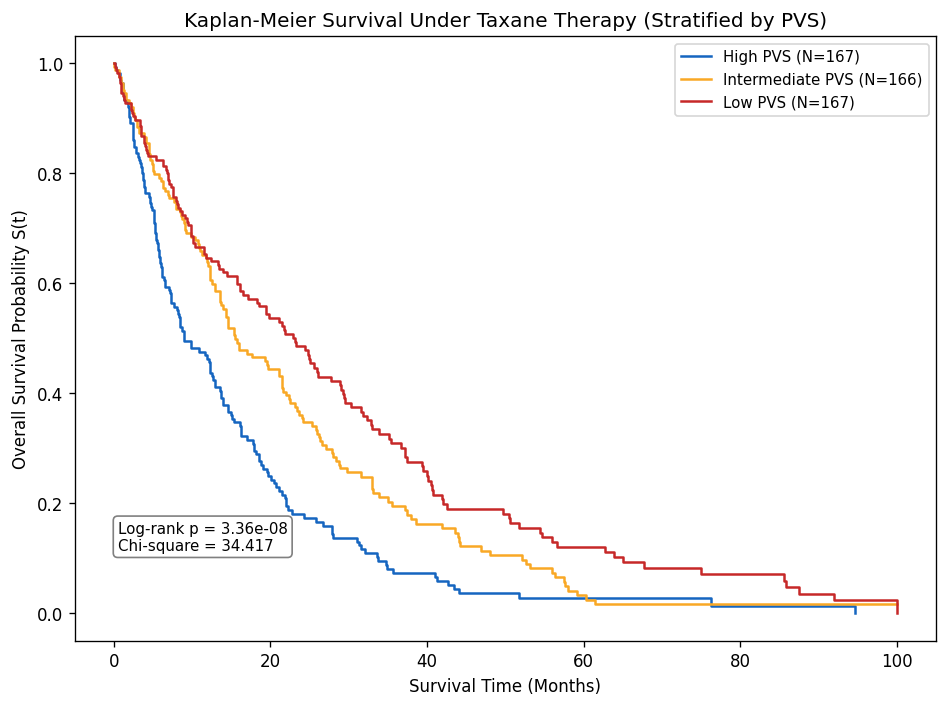

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {"High": "#1565c0", "Intermediate": "#f9a825", "Low": "#c62828"}

for group, color in colors.items():
    mask = df.PVS_group == group
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, "duration_months"], df.loc[mask, "event_observed"],
            label=f"{group} PVS (N={mask.sum()})")
    kmf.plot_survival_function(ax=ax, color=color, ci_show=False)

result = multivariate_logrank_test(df["duration_months"], df["PVS_group"], df["event_observed"])
ax.text(0.05, 0.15, f"Log-rank p = {result.p_value:.2e}\nChi-square = {result.test_statistic:.3f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"))

ax.set_xlabel("Survival Time (Months)")
ax.set_ylabel("Overall Survival Probability S(t)")
ax.set_title("Kaplan-Meier Survival Under Taxane Therapy (Stratified by PVS)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("figure1_km_pvs.png", dpi=300)
plt.show()


In [6]:
df.to_csv("pvs_cohort_scores.csv", index=False)
pd.Series(weights).to_csv("pvs_fitted_weights.csv", header=["coef"])
print("Saved: pvs_cohort_scores.csv, pvs_fitted_weights.csv, figure1_km_pvs.png")


Saved: pvs_cohort_scores.csv, pvs_fitted_weights.csv, figure1_km_pvs.png


---
### Next steps for a real manuscript
- Replace the Section 1 simulation with real TCGA clinical + expression/methylation/CNV data (e.g. via
  `TCGAbiolinks`, `cBioPortal` API) joined to DepMap/GDSC lookups for the same tumor types or matched
  cell lines.
- Re-fit and cross-validate the Cox model (e.g. k-fold, or a held-out validation cohort) before treating any
  weight or hazard ratio as final.
- Report the actual sample size, censoring rate, and confidence intervals — a single log-rank p-value from a
  simulated cohort is not evidence of clinical utility.
